In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from episbi.models import Transition, compartment_model
from episbi.prior import UniformPrior
from episbi.inference import SBIEngine
from episbi import simulate_for_sbi
from episbi.metric import evaluate_prediction_windows
from episbi.utils import plot_prediction_windows

/etc/python/sitecustomize.py:117: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  mod = _original_import(name, globals, locals, fromlist, level)


In [2]:
model_type = "deterministic"
simulator_extra_kwargs = {"observation_error": "poisson"}

initial_conditions = {"S": 99_990, "E": 0, "I": 10, "R": 0}
theta_true = {"beta": 0.80, "kappa": 0.30, "gamma": 0.35}
total_days = 100
inference_days = 80
forecast_days = total_days - inference_days
output_name = "E_to_I"

In [3]:
compartments = ["S", "E", "I", "R"]
transitions = [
    Transition("S", "E", "beta * S * I / N", name="S_to_E"),
    Transition("E", "I", "kappa * E", name="E_to_I"),
    Transition("I", "R", "gamma * I", name="I_to_R"),
]
param_names = ["beta", "kappa", "gamma"]
observed = {"transitions": [output_name]}

In [4]:
seir_model = compartment_model(
    compartments=compartments,
    transitions=transitions,
    param_names=param_names,
    model_type=model_type,
    initial_conditions=initial_conditions,
    observed=observed,
)

print(seir_model.show())

Model type: deterministic
Compartments: S, E, I, R
Parameters: beta, kappa, gamma
Transitions:
  S_to_E: S -> E, rate=beta * S * I / N
  E_to_I: E -> I, rate=kappa * E
  I_to_R: I -> R, rate=gamma * I
Observed:
  E_to_I


In [5]:
prior = UniformPrior(
    bounds={
        "beta": (0.01, 1.5),
        "kappa": (0.01, 0.5),
        "gamma": (0.01, 0.5),
    }
)

In [6]:
num_prior_simulations = 100_000

thetas, xs = simulate_for_sbi(
    prior=prior,
    simulator=seir_model,
    num_simulations=num_prior_simulations,
    total_days=total_days,
    seed=0,
    simulator_kwargs=simulator_extra_kwargs,
)

thetas_train = thetas
xs_train = xs[:, :inference_days, :]

thetas.shape, xs.shape, xs_train.shape

((100000, 3), (100000, 100, 1), (100000, 80, 1))

In [7]:
observed_result = seir_model(
    theta_true,
    total_days=total_days,
    seed=0,
    **simulator_extra_kwargs,
)
observed = observed_result[output_name]
obs_train = observed[:inference_days]

observed.shape, obs_train.shape

((100,), (80,))

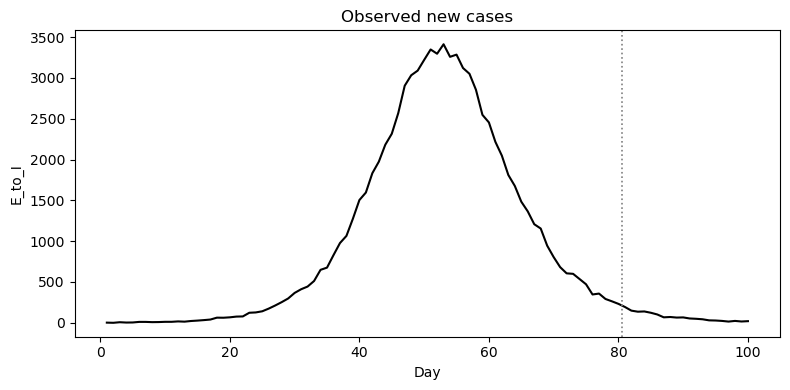

In [8]:
days = np.arange(1, total_days + 1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(days, observed, color="black", linewidth=1.5)
ax.axvline(inference_days + 0.5, color="gray", linestyle=":", linewidth=1.2)
ax.set_xlabel("Day")
ax.set_ylabel(output_name)
ax.set_title(f"Observed new cases")
fig.tight_layout()
plt.show()

## Inference - NPE-LSTM

In [ ]:
engine = SBIEngine(batch_size=256)
result = engine.run_npe_lstm(
    obs_data=obs_train,
    prior=prior,
    thetas=thetas_train,
    xs=xs_train,
    input_dim=1,
    num_samples=1_000,
    show_train_summary=False,
)

posterior = result["posterior"]
posterior_samples = result["samples"].detach().cpu().numpy()
posterior_samples.shape

[*] Running NPE (use_lstm=True) with batch size 256...


In [ ]:
param_df = pd.DataFrame(posterior_samples, columns=prior.names)
param_df.describe()

In [ ]:
fig, axes = plt.subplots(1, len(prior.names), figsize=(4 * len(prior.names), 3))

if len(prior.names) == 1:
    axes = [axes]

for ax, name in zip(axes, prior.names):
    ax.hist(param_df[name], bins=40, color="steelblue", alpha=0.8)
    ax.axvline(theta_true[name], color="black", linestyle="--", linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel("Posterior sample")
    ax.set_ylabel("Count")

fig.tight_layout()
plt.show()

In [ ]:
posterior_predictive = []

for _, theta in param_df.iloc[:300].iterrows():
    theta_dict = prior.to_dict(theta)
    sim = seir_model(
        theta_dict,
        total_days=total_days,
        **simulator_extra_kwargs,
    )[output_name]
    posterior_predictive.append(sim)

posterior_predictive = np.stack(posterior_predictive)[:, :, None]
posterior_predictive.shape

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_prediction_windows(
    y_obs=observed[:, None],
    prediction=posterior_predictive,
    inference_days=inference_days,
    forecast_days=forecast_days,
    output_index=0,
    title=f"Posterior predictive {output_name}",
    ylabel=output_name,
    ax=ax,
)
fig.tight_layout()
plt.show()

In [ ]:
ppc_result = evaluate_prediction_windows(
    y_obs=observed[:,None],
    prediction=posterior_predictive,
    inference_days=inference_days,
    forecast_days=forecast_days,
    output_names=["incidence"],
)

ppc_result